In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy import special as sp
filename = "/Users/summer/Downloads/Dineutron/nn_dineutron_spectrum.h5"
L = 48

by_Psq = {} 

with h5py.File(filename, "r") as f:
    mN = f["mN/E0"][()]
    for gname, g in f.items(): #loop through every top-lever group
        if gname == "mN":
            continue  #skip mass group
        q1 = g["Psq_N1"][()][0] #read each momentum label Psq_N1 =  nx^2 + ny^2 + nz^2
        q2 = g["Psq_N2"][()][0]
        by_Psq.setdefault(q1, []).append(g["E_N1"][()]) #put the entire E_N1 array into the dictionary list associated with N1's momentum label Psq_N1
        by_Psq.setdefault(q2, []).append(g["E_N2"][()])

#numpy array of JUST the keys of the by_Psq dictionary
Psq = np.array(sorted(by_Psq)) 
#numpy array of the physical momentum squared corresponding to each Psq value
p2 = (2*np.pi/L)**2 * Psq 
#2D numpy array where each row corresponds to one Psq value (key of dictionary)
#Column 0: average of all element 0 central energies 
# Columnn 1: average of all element 1 bootstrap (repeat until 5000th boostrap)
E = np.array([np.mean(by_Psq[q], axis=0) for q in Psq]) 

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

rng = np.random.default_rng(1234)

filename = "/Users/summer/Downloads/Dineutron/nn_dineutron_spectrum.h5"
L = 48.0
 
punit = 2*np.pi/L
punit2 = punit**2


def boot_err(x):
    return np.std(x[1:], ddof=1) #assumes x[0] is the central value, and x[1:] are the bootstrap samples


def get_dE(g):
    for key in ["dE_NN", "dE", "DeltaE", "E0", "dE0"]:
        if key in g:
            return np.array(g[key])
    raise KeyError(f"No energy shift found. Keys are {list(g.keys())}")


def get_irrep(name):
    return name.split("_Psq")[0]


def get_Psq_total(name):
    m = re.search(r"Psq(\d+)", name)
    if m is None:
        raise ValueError(f"Could not read total Psq from {name}")
    return int(m.group(1))


def get_level(name):
    m = re.search(r"level(\d+)", name)
    return int(m.group(1)) if m is not None else 0


def dvec_from_d2(d2):
    nmax = int(np.ceil(np.sqrt(max(d2, 1)))) + 2
    best = None
    for nx in range(nmax + 1):
        for ny in range(nmax + 1):
            for nz in range(nmax + 1):
                v = np.array([nx, ny, nz], dtype=int)
                if int(np.dot(v, v)) == int(d2):
                    cand = tuple(sorted(v))
                    if best is None or cand < best:
                        best = cand
    if best is None:
        raise ValueError(f"No integer momentum representative found for Psq={d2}")
    return np.array(best, dtype=int)


raw_levels = []

with h5py.File(filename, "r") as f:
    mN = np.array(f["mN/E0"])
    m = float(mN[0]) #central mass

    for name, g in f.items(): #loop through every top-level group
        if name == "mN":
            continue #skip mN

        irrep = get_irrep(name)
        Psq_tot = get_Psq_total(name)
        level_index = get_level(name)

        N1 = int(np.array(g["Psq_N1"])[0])
        N2 = int(np.array(g["Psq_N2"])[0])
        dE = get_dE(g)

        #Because mN contains 5001 values, E1 and E2 also contains 5001 values 
        E1 = np.sqrt(mN**2 + punit2*N1) # E^2 = m^2 + p^2, where p^2 = (2*pi/L)^2 * N1
        E2 = np.sqrt(mN**2 + punit2*N2)
        E_NN = dE + E1 + E2 #total interacting energy in og lattice frame 

        E_cm = np.sqrt(E_NN**2 - punit2*Psq_tot) #convert to center of mass energy 
        kstar2 = E_cm**2/4 - mN**2 #calculate the square of the relative momentum
        q2 = kstar2/punit2 #makes momentum dimensionless by dividing by (2*pi/L)^2

        #save for one level
        raw_levels.append({
            "name": name,
            "irrep": irrep,
            "Psq_tot": Psq_tot,
            "level_index": level_index,
            "pair": tuple(sorted((N1, N2))),
            "Ecm_boot": E_cm,
            "q2_boot": q2,
        })

raw_levels = sorted(raw_levels, key=lambda r: (r["Psq_tot"], r["irrep"], r["level_index"], r["name"]))


Text(0, 0.5, 'E_cm')

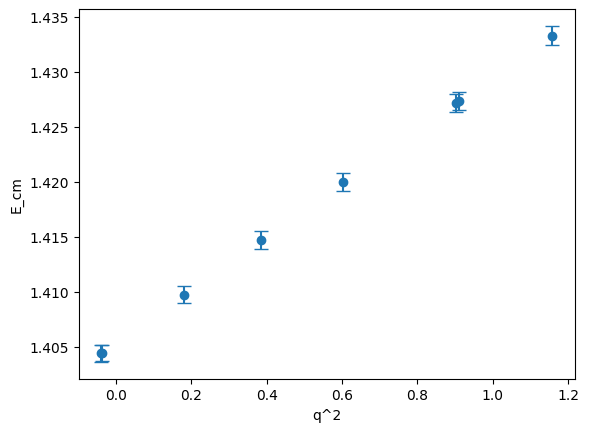

In [5]:
q_squared = []
energy_values = []
energy_errors = []

for level in raw_levels:
    q_squared.append(level["q2_boot"][0])

    central_Ecm = level["Ecm_boot"][0]
    energy_values.append(central_Ecm)

    error_Ecm = boot_err((level["Ecm_boot"]))
    energy_errors.append(error_Ecm)

plt.errorbar(q_squared, energy_values, yerr = energy_errors, fmt='o', capsize=5)
plt.xlabel("q^2")
plt.ylabel("E_cm")

F Function

In [6]:
'''
Finite-volume function
'''

# Let us work with ideentical particles throughout
xi = 0.5 # symmetry factor
twoPi = 2 * np.pi
m_sq = m*m

# sqrt with branch cut aligned on positive real axis
def mySqrt(z):
   return 1j * np.sqrt( -z )

# CM momentum
def q_cm(s):
    return 0.5 * mySqrt( s - 4.0 * m**2 )

# Phase space factor
def phase_space(s):
    return xi * q_cm(s) / ( 8.0 * np.pi * np.sqrt(s) )

# inner product for two list (native)
def dot(A, B):
   return np.dot(A,B) #inner1d(A,B) #np.sum( A * B, axis=1)

# Function to generate 3-tuple "n = (nx,ny,nz)" list
# subject to the constraint nx^2 + ny^2 + nz^2 <= nShell^2,
# where "nShell" indicates the number of shells
def generateIntList( nShell ):
    intList = []
    rawList = np.array(np.arange(-nShell,nShell+1))
    for i in itertools.product(rawList,rawList,rawList):
        tmpList = np.array(i)
        if ( np.dot(tmpList,tmpList) <= nShell*nShell ):
            intList.append(tmpList)

    return np.asarray(intList)

# returns the unit vector of a vector "A"
def unit_vector( A ):
    if( all( A==0 ) ):
        return A
    else:
        return A / np.sqrt( np.dot(A,A) )

# special multiply for array of arrays (A) and an array (B), used in the zeta function
def multiply( A, B ):
   nA = len(A)
   return A.reshape(nA,1) * np.tile( B, (nA,1) )
   ### First, reshape A array to 2d (1xnA), and then copy b vector nA time to make (nA x nB) array
   ### alternatively, do (A.reshape(nA,1)).dot( B.reshape(1,3) )

# returns a Lorentz boosted four vector "(A0,A)" given some boost velocity "beta"
def lorentzBoost( A0, A, beta ):
    gamma = 1.0 / np.sqrt( 1.0 - np.dot(beta,beta) )
    Apar  = multiply( A.dot( unit_vector(beta) ), unit_vector(beta) )
    Aper  = A - Apar
    A0_prime = gamma * ( A0 - A.dot( beta ) )
    A_prime  = gamma * ( Apar - multiply( A0, beta ) ) + Aper
    return A0_prime, A_prime


# cutoff function (alpha input is dimensionless)
def cutoff( qcm_sq, kcm_sq, alpha, L ):
    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    return np.exp( -alpha * ( kcm_sq - qcm_sq ) )

#
# KSS Zeta function for ell = m_ell = 0, given "qcm_sq", total momentum "nP"
# This function is in units of L / 2pi, e.g. m1 -> m1 * L / (2 * pi).
#

# Finite volume function F, given Ecm (units of mass), nP, alpha (dimensionless), and L (units of mass)
# MUST call generateIntList first and use global intList from its output
#
# Note: We chose to have Ecm as input rather than E for convenience in plotting/ pole finding. Coding it the other way works too,
# we are just saving ourselves a couple transformations which are not needed for our purposes.
#
def F_function(Ecm, nP, alpha, L):
    P = twoPi * nP / L
    P_sq = np.dot(P, P)

    E = np.sqrt(Ecm**2 + P_sq)
    s = Ecm**2

    eps = 1e-16

    qcm_value = q_cm(s + 1j * eps)
    qcm_sq = qcm_value**2
    rho = phase_space(s + 1j * eps)

    beta = P / E

    # Each row of k is one allowed 3-momentum
    k = (twoPi / L) * intList

    # Squared magnitude of each momentum vector
    k_sq = np.sum(k**2, axis=1)

    # Energy associated with each momentum vector
    omega = np.sqrt(m_sq + k_sq)

    omega_cm, k_cm = lorentzBoost(omega, k, beta)

    # Squared magnitude of each boosted momentum
    k_cm_sq = np.sum(k_cm**2, axis=1)

    cutoff_values = cutoff(
        qcm_sq,
        k_cm_sq,
        alpha,
        L
    )

    tmp = cutoff_values * omega_cm / omega
    tmp = tmp / (qcm_sq - k_cm_sq)

    sum0 = (
        xi / (2.0 * Ecm * L**3)
    ) * np.sum(tmp)

    alpha_dim = (L / twoPi)**2 * alpha

    z = np.sqrt(alpha_dim) * qcm_value

    integral = (
        xi / (4.0 * np.pi**2 * Ecm)
    ) * (
        np.sqrt(0.25 * np.pi / alpha_dim)
        * np.exp(alpha_dim * qcm_sq)
        - 0.5
        * np.pi
        * qcm_value
        * sp.erfi(z)
    )

    return 1j * rho + sum0.real + integral

In [7]:
#calculate q2, F, F_pv for each data point
m = float(mN[0])
m_sq = m**2

nShell = 5
intList = generateIntList(nShell)

alpha = 0.05
L = 48.0
print("m =", m)
print("m_sq =", m_sq)
print("nShell =", nShell)
print("number of momentum vectors =", len(intList))

q2_values = []
F_values = []
F_pv_values = []

eps = 1e-16

for level in raw_levels:
    E_cm = float(level["Ecm_boot"][0])
    nP = dvec_from_d2(level["Psq_tot"])
    print(m, nP, E_cm)
    F_value = F_function(E_cm, nP, alpha, L)
    F_values.append(F_value)

    #F_pv
    s = E_cm **2 
    rho_value = phase_space(s + 1j * eps)

    F_pv_value = (F_value - 1j * rho_value).real
    F_pv_values.append(F_pv_value)

    #q2
    q2_values.append(float(level["q2_boot"][0]))
    

m = 0.7026827020795523
m_sq = 0.4937629798018209
nShell = 5
number of momentum vectors = 515
0.7026827020795523 [0 0 0] 1.404480193149725
0.7026827020795523 [0 0 0] 1.427387430256371
0.7026827020795523 [0 0 1] 1.4097814949159677
0.7026827020795523 [0 0 1] 1.4333221966427518
0.7026827020795523 [0 1 1] 1.4147421255240087
0.7026827020795523 [1 1 1] 1.4199751076807943
0.7026827020795523 [0 0 2] 1.4044221450218684
0.7026827020795523 [0 0 2] 1.4271811314910883


In [8]:
def M_function(F):
    return -1.0 / F

Plot M vs q^2 (actual data)

In [9]:
M_real_values = []
M_imag_values = []

for F_value in F_values:
    M_value = M_function(F_value)
    M_real_values.append(M_value.real)
    M_imag_values.append(M_value.imag)

Text(0.5, 1.0, 'M vs q^2Imaginary part')

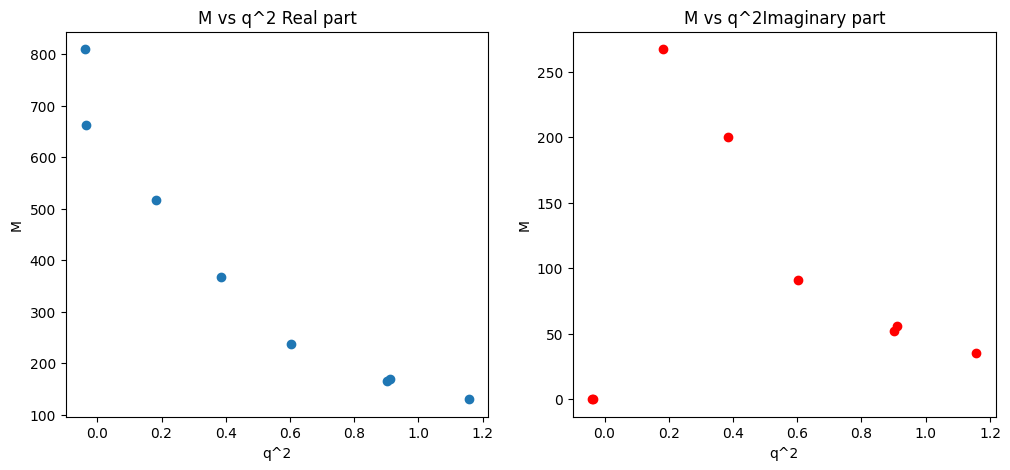

In [10]:
plt.figure(figsize=(12, 5))
ax1 = plt.gcf().add_subplot(121)
ax2 = plt.gcf().add_subplot(122)

ax1.scatter(q2_values, M_real_values, label="Real part of M")
ax1.set_xlabel("q^2")
ax1.set_ylabel("M")
ax1.set_title("M vs q^2 Real part")

ax2.scatter(q2_values , M_imag_values, label="Imaginary part of M", color = 'red')
ax2.set_xlabel("q^2")
ax2.set_ylabel("M")
ax2.set_title("M vs q^2Imaginary part")

Plot q^* cot delta vs q^2 (actual data)

In [11]:
q_cot_delta_values = []

for i in range(len(raw_levels)):

    #get level
    level = raw_levels[i]

    #get F_pv 
    F_pv_value = F_pv_values[i]

    #CM 
    E_cm = float(level["Ecm_boot"][0])

    #q* cot(delta = -(8* pi * E_cm / xi)(F_pv)
    q_cot_delta = -(8.0 * np.pi * E_cm / xi) * F_pv_value

    q_cot_delta_values.append(q_cot_delta.real)

Text(0, 0.5, 'qcotdelta')

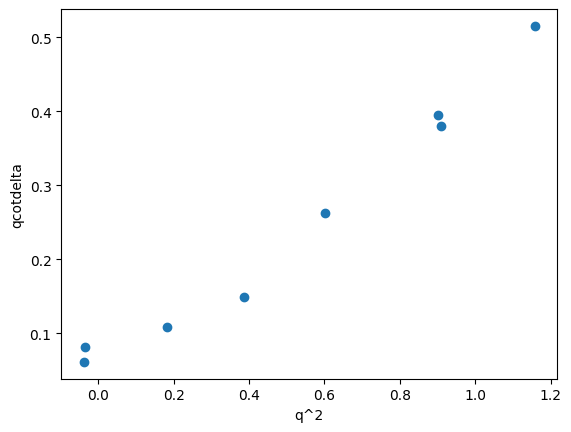

In [12]:
plt.scatter(q2_values, q_cot_delta_values)
plt.xlabel("q^2")
plt.ylabel("qcotdelta")


Plot F vs E^* / m vs (synthetic)

In [13]:
m = float(mN[0])
e_cm_inputs = np.linspace(2 *m, 10.2 * m, 1000)
shell = 5
alpha = 0.125
intList = generateIntList(shell)
P = np.array([0.0, 0.0, 0.0])

linspace_F_values = []
linspace_M_real_values = []
linspace_M_imag_values= []

for i in range(len(e_cm_inputs)):
    to_append_linspace_F = F_function(e_cm_inputs[i], P, alpha, L)
    linspace_F_values.append(to_append_linspace_F)

    to_append_linspace_M_real = (M_function(linspace_F_values[i])).real
    linspace_M_real_values.append(to_append_linspace_M_real)

    to_append_linspace_M_imag = (M_function(linspace_F_values[i])).imag
    linspace_M_imag_values.append(to_append_linspace_M_imag)

In [15]:
print(float(mN[0]))

0.7026827020795523


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'F vs E^*/m')

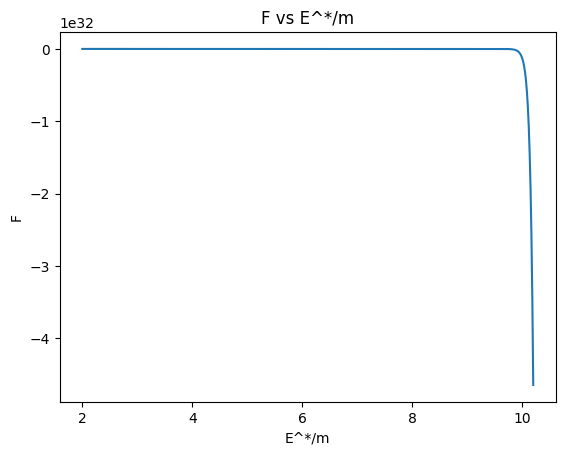

In [14]:
plt.plot(e_cm_inputs / m, linspace_F_values)

plt.xlabel("E^*/m")
plt.ylabel("F")
plt.title("F vs E^*/m")

Text(0.5, 1.0, 'M vs E^*/m Imaginary part')

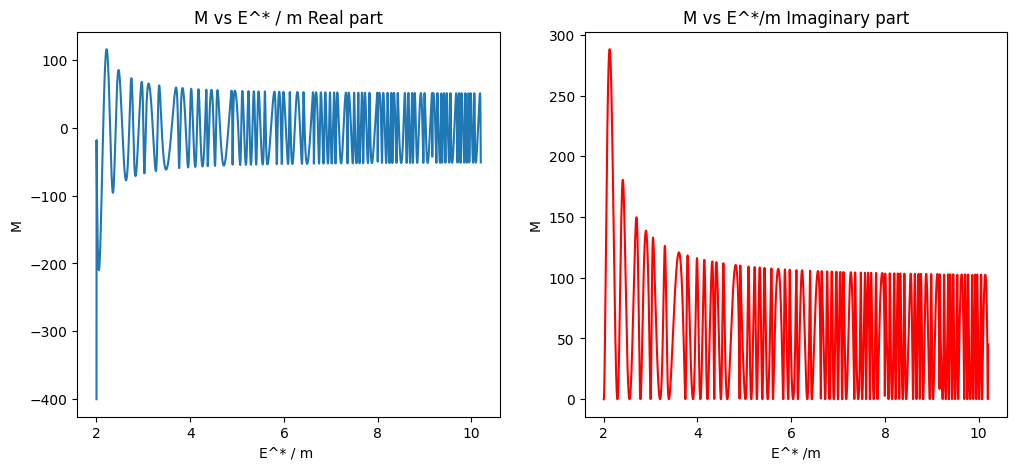

In [128]:
plt.figure(figsize=(12, 5))
ax4 = plt.gcf().add_subplot(121)
ax5 = plt.gcf().add_subplot(122)

ax4.plot(e_cm_inputs / m, linspace_M_real_values, label="Real part of M")
ax4.set_xlabel("E^* / m ")
ax4.set_ylabel("M")
ax4.set_title("M vs E^* / m Real part")

ax5.plot(e_cm_inputs / m , linspace_M_imag_values, label="Imaginary part of M", color = 'red')
ax5.set_xlabel("E^* /m")
ax5.set_ylabel("M")
ax5.set_title("M vs E^*/m Imaginary part")

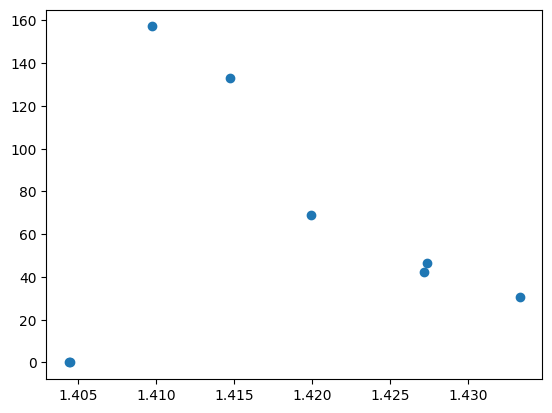

In [115]:
plt.scatter(energy_values, M_imag_values)

Plot qcotdelta vs q^2

45


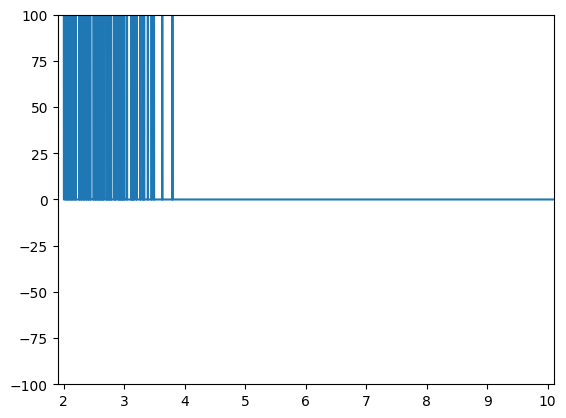

In [16]:
import numpy as np
import matplotlib.pyplot as plt

m = float(mN[0])
L = 48

d = np.array([0, 0, 0])
punit = 2 * np.pi / L
Pvec = punit * d
P2 = np.dot(Pvec, Pvec)

E_min = 2 * m
E_max = 10 * m

levels = []

E_grid = np.linspace(2 * m, 10.2 * m, 8000)
F = np.zeros_like(E_grid)

for i in range(-5, 6):
    for j in range(-5, 6):
        for k in range(-5, 6):

            n1 = np.array([i, j, k])
            n2 = d - n1

            p1 = punit * n1
            p2 = punit * n2

            E_lab = (np.sqrt(np.dot(p1, p1) + m**2) +
                     np.sqrt(np.dot(p2, p2) + m**2))
           
            E_star = np.sqrt(E_lab**2 - P2)
            levels.append(E_star)

levels = np.unique(np.round(levels, 12))

for E_star in levels:
    idx = np.argmin(np.abs(E_grid - E_star))
    F[idx] = 1000 #np.inf

print(len(levels))

plt.plot(E_grid / m, F)
plt.ylim(-100,100)
plt.xlim(1.9, 10.1)
plt.show()
